# Algorytm Scale-Invariant Feature Transform (SIFT)
_Kurs "Analiza danych obrazowych i multimedialnych" 26L_

- **Zespół 4:** Cong Minh Vu, Mateusz Szulc, Szymon Ochnio, Mateusz Kwiatkowski
- **Data realizacji:** maj 2026

### Opis algorytmu

Algorytm **SIFT (Scale-Invariant Feature Transform)** służy do detekcji i szczegółowego opisu lokalnych cech obrazu, co pozwala na rozpoznawanie i dopasowywanie tych samych obiektów na różnych zdjęciach.

W wyniku swojego działania wyznacza on punkty charakterystyczne obrazu (key points), które cechują się:
- niewrażliwością na jednorodne zmiany skali obrazu i jego rotację,
- częściową niewrażliwością na zmiany oświetlenia i położeicnie kamery (perspektywę).

Proces wykrywania punktów charakterystycznych składa się z kilku etapów:
1. **Detekcja potencjalnych punktów charakterystycznych** - obraz jest wielokrotnie rozmywany i skalowany. Badanie różnic między rozmyciami pozwala na wykrycie potencjalnych lokalnych cech w różnych skalach. Zapewnia to niewrażliwość na jednorodne zmiany skali obrazu.
2. **Lokalizacja punktów charakterystycznych** - wyznacza się dokładną lokalizację punktów w dziedzinie subpixeli, a następnie odrzuca punkty znajdujące się na krawędziach lub takie o niskim kontraście.
3. **Przypisanie orientacji** - przypisuje punktom dominujący kierunek gradientu ich otoczenia. Pozwala to na zapewnienie niewrażliwości na rotację obrazu.
4. **Budowa deskryptorów** - opisuje punkty poprzez charakterystyczne wektory 128 cech utworzone poprzez lokalne zastosowanie metody HOG w ich otoczeniu. Pozwala to na zapewnienie wysokiej rozróżnialności punktów i uprosza proces poszukiwania odpowiadających punktów między obrazami.

Algorytm SIFT posiada liczne zastosowania i jest powszechnie wykorzystywany m.in. do: rozpoznawania obiektów, śledzenia ruchu, wirtualnej rzeczywistości (AR), tworzenia panoram (stitching), modelowania 3D.

**Przydatne źródła:**
- [Oficjalny tutorial OpenCV dla metody SIFT](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html)
- [Artykuł oryginalny: David G. Lowe (2004) "Distinctive Image Features from Scale-Invariant Keypoints"](https://www.cs.ubc.ca/~lowe/papers/ijcv04.pdf)
- [Opis algorytmu SIFT (Wikipedia)](https://en.wikipedia.org/wiki/Scale-invariant_feature_transform)
- [Repozytorium kodu OpenCV z przykładami](https://github.com/opencv/opencv)

### Opis implementacji

Nasza implementacja tworzy otoczkę wokół struktur udostępnianych przez bibliotekę `OpenCV` w celu zapewnienia prostej konfiguracji i jednolitego interfejsu. Udostępnione zostają dwie główne klasy:

- Klasa `SiftConfig` umożliwia na skonfigurowanie sposobu dopasowywania punktów charakterystycznych między obrazami. Pozwala m.in. zastosowanie testu Lowe'a do odrzucania fałszywych dopasowań lub na wybór typu matchera - Brute-Force (_BFMatcher_) lub _FLANN_ (szybszy dla dużych obrazów).
- Klasa `SiftMatcher` udostępnia metody umożliwiające proste wykonanie całego procesu od załadowania obrazów, przez ekstrakcję lokalnych cech, aż po porównanie cech obrazów i wizualizację dopasowań.

Zostały one przygotowane poniżej:

In [1]:
from enum import Enum

import cv2
import matplotlib.pyplot as plt
import numpy as np

from dataclasses import dataclass
from typing import Optional, Dict, Any


class SiftMatcherType(Enum):
    BFMatcher = 1
    FLANN = 2


@dataclass
class SiftConfig:
    """Configuration parameters for SIFT matcher."""
    matcher_type: SiftMatcherType = SiftMatcherType.BFMatcher
    norm_type: int = cv2.NORM_L2  # cv2.NORM_L2 / cv2.NORM_L1
    ratio_threshold: float = 0.75  # Lowe test threshold
    cross_check: bool = False  # BFMatcher flag ( (wzajemnie najlepsze dopasowania)
    flann_index_params: Optional[Dict[str, Any]] = None
    flann_search_params: Optional[Dict[str, Any]] = None

    def __post_init__(self):
        """Initialize FLANN params."""
        if self.matcher_type == SiftMatcherType.FLANN:
            FLANN_INDEX_KDTREE = 1
            if self.flann_index_params is None:
                self.flann_index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
            if self.flann_search_params is None:
                self.flann_search_params = dict(checks=50)


class SiftMatcher:

    def __init__(self, config: SiftConfig = SiftConfig()):
        self.sift = cv2.SIFT_create()
        self.config = config
        self.matcher = cv2.BFMatcher(cv2.NORM_L2)

        if self.config.matcher_type == SiftMatcherType.BFMatcher:
            self.matcher = cv2.BFMatcher(
                normType=self.config.norm_type,
                crossCheck=self.config.cross_check
            )
        elif self.config.matcher_type == SiftMatcherType.FLANN:
            self.matcher = cv2.FlannBasedMatcher(
                self.config.flann_index_params,
                self.config.flann_search_params
            )
        else:
            raise ValueError('Unknown SIFT matcher.')

    @staticmethod
    def load_image(path: str) -> np.ndarray:
        """
        Loads image from path.
        :param path: Path to image
        :return: Loaded image
        """
        img = cv2.imread(path)
        if img is None:
            raise FileNotFoundError(f"Failed to load image: {path}")
        return img

    def extract_features(self, image: np.ndarray):
        """
        Extracts feature points and their descriptors from the image.
        :param image: Image to extract features from
        :return: Tuple of keypoints and descriptors
        """
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        keypoints, descriptors = self.sift.detectAndCompute(gray, None)
        return keypoints, descriptors

    @staticmethod
    def draw_features(image: np.ndarray, keypoints: list, rich_display: bool = False) -> np.ndarray:
        """
        Draws local features onto the image.
        :param image: Source image with extracted features
        :param keypoints: Key points of the image
        :param rich_display: Indicates whether to display additional details, such as orientation
        :return: Image with drawn local features
        """
        flag = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS if rich_display else cv2.DRAW_MATCHES_FLAGS_DEFAULT

        result_image = cv2.drawKeypoints(
            image,
            keypoints,
            None,
            color=(0, 0, 255),
            flags=flag
        )
        return result_image

    def find_matches(self, descriptors1: np.ndarray, descriptors2: np.ndarray) -> list:
        """
        Discovers best feature matches using configured matcher.
        :param descriptors1: Descriptors of the first image features
        :param descriptors2: Descriptors of the second image features
        :return: Matching feature points
        """
        if self.config.matcher_type == SiftMatcherType.BFMatcher and self.config.cross_check:
            raw_matches = self.matcher.match(descriptors1, descriptors2)
            good_matches = sorted(raw_matches, key=lambda x: x.distance)
        else:
            # KNN + Lowe test
            raw_matches = self.matcher.knnMatch(descriptors1, descriptors2, k=2)
            good_matches = []

            for m, n in raw_matches:
                if m.distance < self.config.ratio_threshold * n.distance:
                    good_matches.append(m)

        return good_matches

    @staticmethod
    def draw_matches(img1, kp1, img2, kp2, matches) -> np.ndarray:
        """
        Draws lines between matching feature points between 2 images.
        :param img1: First image
        :param kp1: Feature points of the first image
        :param img2: Second image
        :param kp2: Feature points of the second image
        :param matches: Matching features
        :return: Image stitch with matches
        """

        result_image = cv2.drawMatches(
            img1, kp1, img2, kp2, matches, None,
            matchColor=(0, 255, 0),
            singlePointColor=None,
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )
        return result_image

    @staticmethod
    def show_image(title: str, image: np.ndarray):
        """
        Displays image on screen.
        :param title: Title of image
        :param image: Image to display
        """
        img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(15, 10))
        plt.title(title)
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()


### Prezentacja wyników działania
Zaczniemy od przedstawienia detekcji lokalnych cech obrazu. Po wczytaniu obrazu wyznaczamy jego punkty charakterystyczne i zwizualizujemy je na tym samym obrazie:

In [2]:
matcher_config = SiftConfig()  # BFMatcher with 0.75 Lowe threshold by default
sift = SiftMatcher(matcher_config)

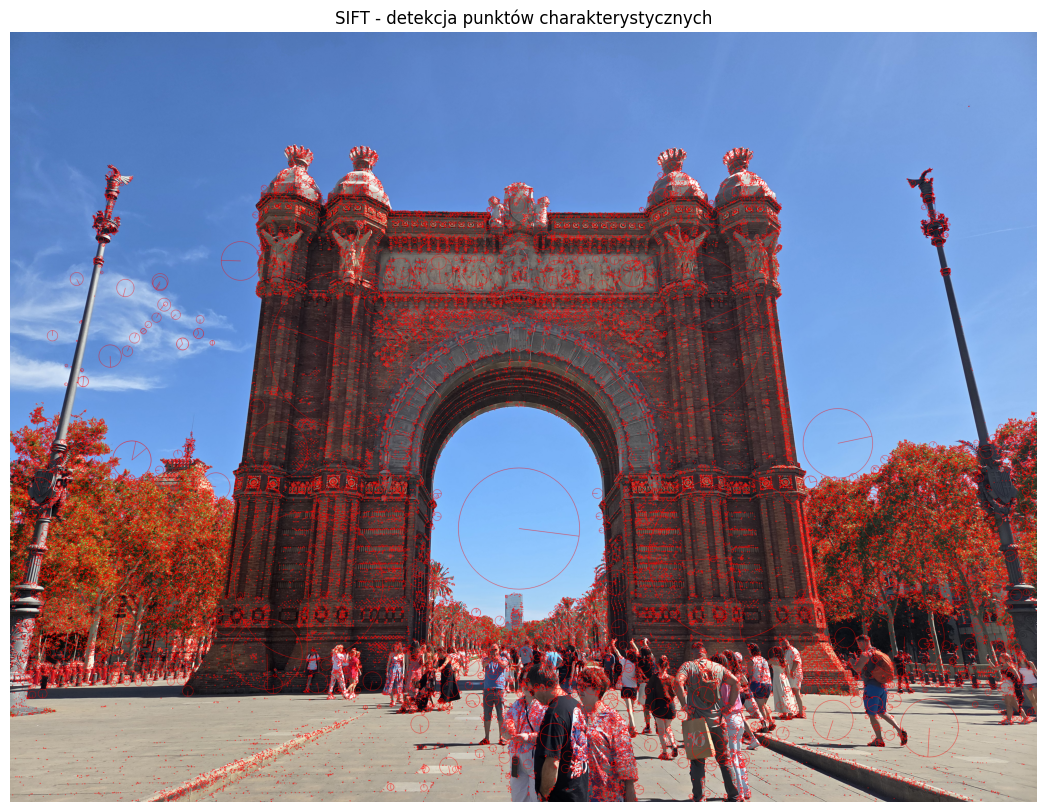

In [3]:
image_path = 'set2/ref.png'  # replace with valid file path to your image
image1 = SiftMatcher.load_image(image_path)

features1, descriptors1 = sift.extract_features(image1)
image_with_features = SiftMatcher.draw_features(image1, features1, rich_display=True)

SiftMatcher.show_image('SIFT - detekcja punktów charakterystycznych', image_with_features)

Punkty charakterystyczne zostały zaznaczone na obrazie za pomocą czerwonych obręczy przedstawiających również wielkość oraz orientację punktów, co jest możliwe dzięki zastosowaniu parametru `rich_display`.

---

Następnie przedstawimy przykład dopasowania punktów między dwoma obrazami. W tym celu dokonamy ekstrakcji cech w drugim obrazie i wyszukamy odpowiednie dopasowania między obrazami (tylko 1000 dopasowań dla lepszej widoczności):

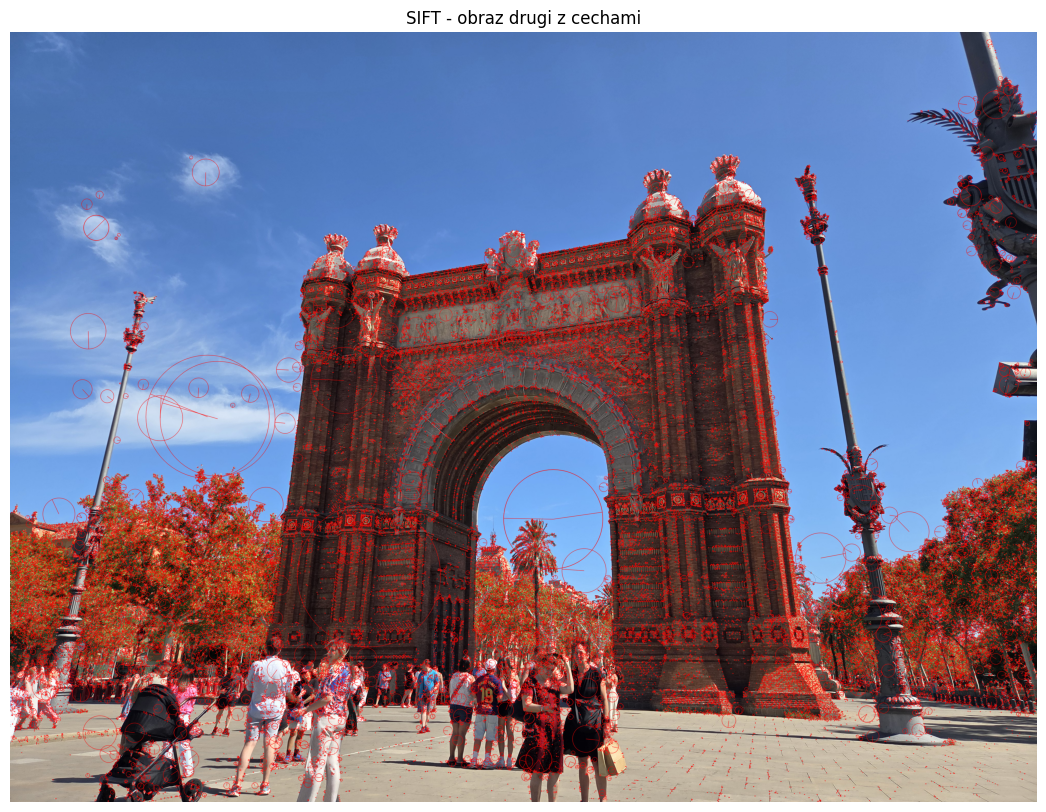

In [4]:
image_path = 'set2/mod.png'  # replace with valid file path to your image
image2 = SiftMatcher.load_image(image_path)

features2, descriptors2 = sift.extract_features(image2)
image_with_features = SiftMatcher.draw_features(image2, features2, rich_display=True)

SiftMatcher.show_image('SIFT - obraz drugi z cechami', image_with_features)

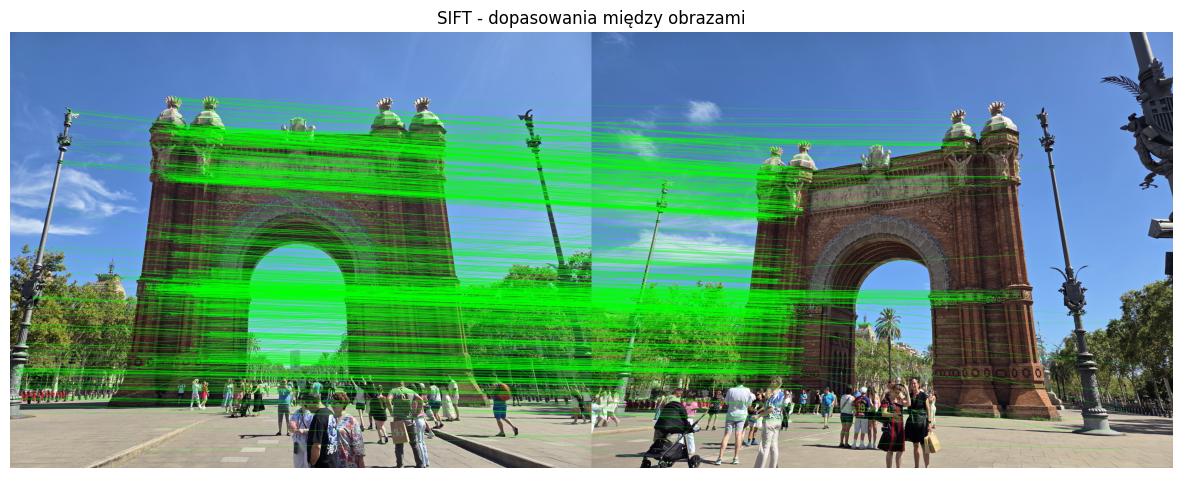

In [5]:
good_matches = sift.find_matches(descriptors1, descriptors2)
comparison_image = SiftMatcher.draw_matches(image1, features1, image2, features2, good_matches[:1000])

SiftMatcher.show_image('SIFT - dopasowania między obrazami',comparison_image)

### Weryfikacja eksperymentalna